In [1]:
import json
import pandas as pd
from google.cloud import storage
from google.oauth2 import service_account
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
credentials = service_account.Credentials.from_service_account_file(
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"]
)

client = storage.Client(
    project=os.environ["GCP_PROJECT_ID"],
    credentials=credentials
)

bucket_name = os.environ["GCP_PROCESSED_BUCKET"]
blobs = client.list_blobs(bucket_name, prefix="processed/")

all_reviews = []
for blob in blobs:
    if not blob.name.endswith(".json"):
        continue
    print(f"Loading {blob.name}...")
    text = blob.download_as_text()
    for line in text.splitlines():
        line = line.strip()
        if line:
            all_reviews.append(json.loads(line))

df = pd.DataFrame(all_reviews)

df["reviewed_at"] = pd.to_datetime(df["reviewed_at"], errors="coerce")

null_count = df["reviewed_at"].isna().sum()
print(f"Null reviewed_at values: {null_count}")

df["year"] = df["reviewed_at"].dt.year
df["month"] = df["reviewed_at"].dt.month

print(f"\nTotal reviews loaded: {len(df)}")
print(df.dtypes)

Loading processed/2012/03/gcash_reviews_2012-03.json...
Loading processed/2012/05/gcash_reviews_2012-05.json...
Loading processed/2012/06/gcash_reviews_2012-06.json...
Loading processed/2012/07/gcash_reviews_2012-07.json...
Loading processed/2012/08/gcash_reviews_2012-08.json...
Loading processed/2012/09/gcash_reviews_2012-09.json...
Loading processed/2012/10/gcash_reviews_2012-10.json...
Loading processed/2012/11/gcash_reviews_2012-11.json...
Loading processed/2012/12/gcash_reviews_2012-12.json...
Loading processed/2013/02/gcash_reviews_2013-02.json...
Loading processed/2013/03/gcash_reviews_2013-03.json...
Loading processed/2013/04/gcash_reviews_2013-04.json...
Loading processed/2013/05/gcash_reviews_2013-05.json...
Loading processed/2013/06/gcash_reviews_2013-06.json...
Loading processed/2013/07/gcash_reviews_2013-07.json...
Loading processed/2013/08/gcash_reviews_2013-08.json...
Loading processed/2013/09/gcash_reviews_2013-09.json...
Loading processed/2013/10/gcash_reviews_2013-10.

In [3]:
df.to_parquet("gcash_reviews.parquet", index=False)

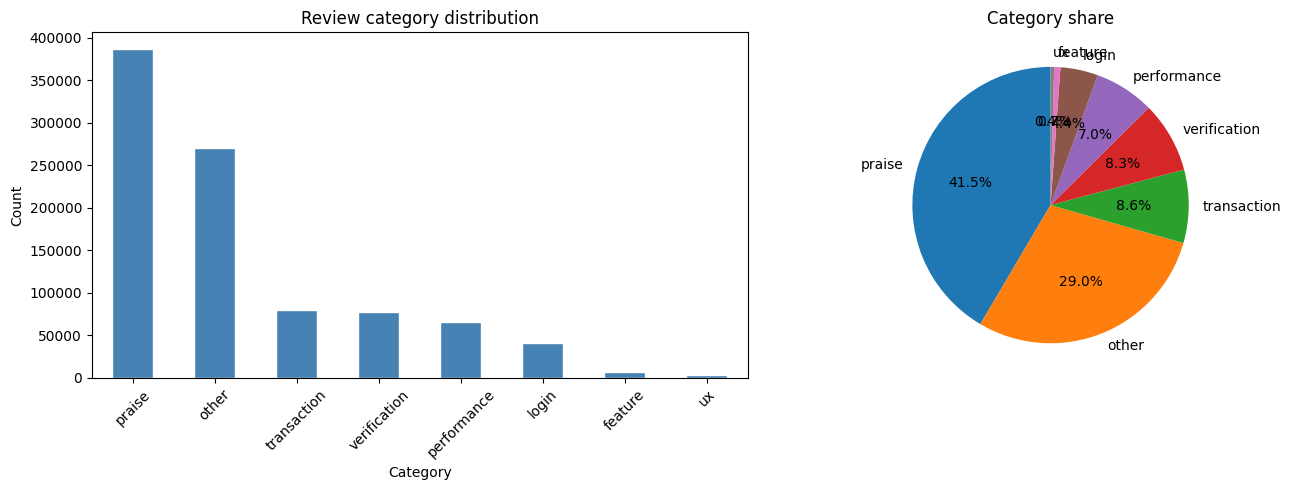


Category counts:
category
praise          386901
other           270662
transaction      79868
verification     77262
performance      65511
login            40983
feature           6875
ux                3803
Name: count, dtype: int64

Other %: 29.0%


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_counts = df["category"].value_counts()
category_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Review category distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

category_counts.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Category share")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print("\nCategory counts:")
print(category_counts)
print(f"\nOther %: {category_counts.get('other', 0) / len(df) * 100:.1f}%")

Note: Initial categorization run had Other %: 50.7%

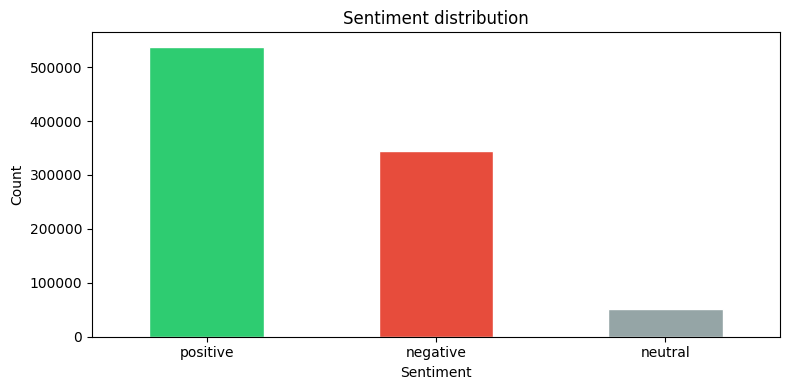


Sentiment counts:
sentiment
positive    537553
negative    343822
neutral      50490
Name: count, dtype: int64


In [5]:
sentiment_counts = df["sentiment"].value_counts()
colors = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

sentiment_counts.plot(
    kind="bar",
    color=[colors.get(s, "gray") for s in sentiment_counts.index],
    edgecolor="white",
    figsize=(8, 4)
)
plt.title("Sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nSentiment counts:")
print(sentiment_counts)

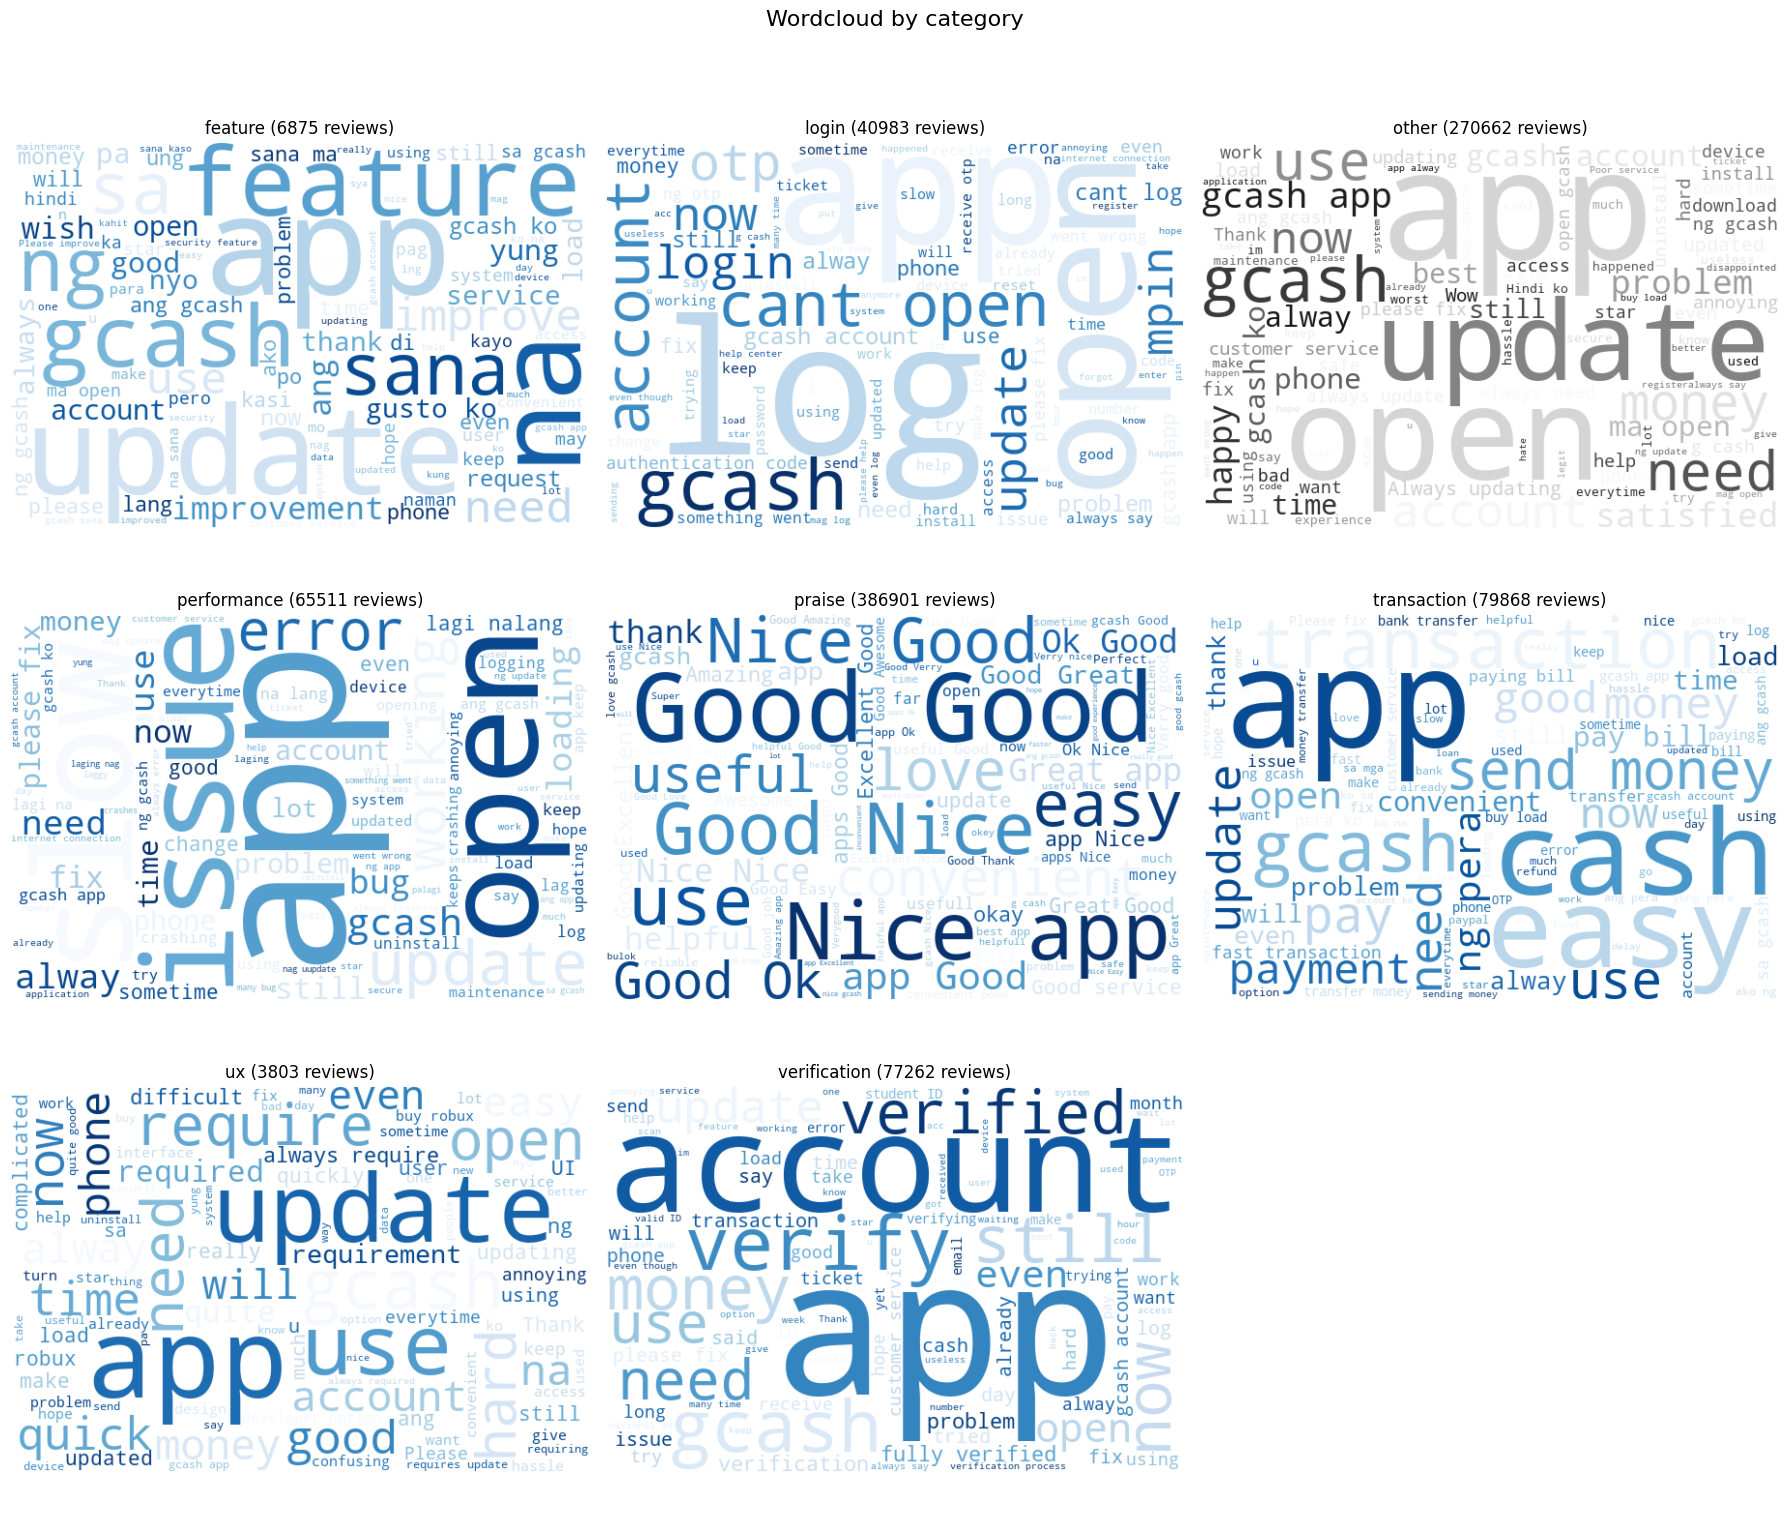

In [6]:
from wordcloud import WordCloud

categories = df["category"].unique()
n_cats = len(categories)
fig, axes = plt.subplots(
    (n_cats + 2) // 3, 3,
    figsize=(18, (n_cats + 2) // 3 * 5)
)
axes = axes.flatten()

for i, category in enumerate(sorted(categories)):
    text = " ".join(
        df[df["category"] == category]["content"]
        .dropna()
        .tolist()
    )
    if not text.strip():
        continue

    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        max_words=100,
        colormap="Blues" if category != "other" else "Greys"
    ).generate(text)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(f"{category} ({len(df[df['category'] == category])} reviews)")
    axes[i].axis("off")

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Wordcloud by category", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# sample 20 reviews from "other" to see what we're missing
other_samples = (
    df[df["category"] == "other"][["content", "score", "sentiment"]]
    .dropna()
    .sample(min(20, len(df[df["category"] == "other"])))
)

for _, row in other_samples.iterrows():
    print(f"[{row['score']}★] {row['content'][:100]}")
    print()

[1★] I can't open my gcash 🥹

[1★] I cant update this apps

[1★] Unable to open app

[5★] Use full app

[5★] it's god

[1★] hndi naka open

[1★] Where's the historyyy walang nalabas

[5★] sometimes is not open

[1★] Napaka bagal mag open

[2★] Sucks

[3★] Convinient

[1★] Always need an update

[1★] Gcash needs to reboot everytime.

[1★] Hindi man lang nag inform na mag uupdate tapos ang tagal pa mag respond sa mga concern tapos wala pa

[1★] i couldn't open it

[3★] Very food

[5★] satisfying

[1★] Already can't use in my other phone what if my phone lost how I recover my money

[5★] Cheap than others

[5★] Satisfactory



A lot of tagalog and one off reviews that are hard to categorize. Emojis will also be categorized as others.